# Library and Data

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


file_paths = {
    "Boston": "data/listings_bs.csv.gz",
    "Los Angeles": "data/listings_la.csv.gz",
    "New York City": "data/listings_ny.csv.gz",
    "San Francisco": "data/listings_sf.csv.gz",
    "Seattle": "data/listings_sea.csv.gz"
}
dfs = []
for city, path in file_paths.items():
    df = pd.read_csv(path, low_memory=False)
    df["city"] = city
    dfs.append(df)

airbnb = pd.concat(dfs, ignore_index=True)

note - Data Assumptions from Inside Airbnb when do analysis 

1. data is not perfect and constructed from scraped and estimation
2. location is NOT exact - from 0-450 feet of the actual address, SO NOT over-interpret previse location differences, use neighborhood-level
3. this is SNAPSHOT data
4. availabity is mismeasured - availability_365 is biased downward & popular listings look “less available”
5. reviews are incomplete and biased 
6. occupancy & revenue are estimated - vars like estimated_revenue_l365d and estimated_occupancy_l365d are model-based info 
7. host behavior is uncertain - hosts might not update calendar on time 


# Structures

In [2]:
print("entire shape: ", airbnb.shape)

print("\nColumns:")
print(list(airbnb.columns))

print("\nDtypes summary:")
print(airbnb.dtypes.value_counts())

print("\nNumeric summary:")
print(airbnb.describe().round(2))

print("\nHead:")
print(airbnb.head(5))

entire shape:  (101259, 80)

Columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availabil

# Key Variable - Price

In [3]:
print(airbnb["price"].sample(20, random_state=1003).tolist())

print("na ratio for price:", airbnb['price'].isna().mean())

price_na_summary = airbnb.groupby("city")["price"].agg(
    total_count="size",
    missing_count=lambda x: x.isna().sum(),
)
price_na_summary["missing_ratio"] = (
    price_na_summary["missing_count"] / price_na_summary["total_count"]
)
print(price_na_summary)

# note: city-dependent missingness

['$1,060.00', '$167.00', '$75.00', nan, '$100.00', '$226.00', '$134.00', '$79.00', '$99.00', '$151.00', nan, '$168.00', '$383.00', '$139.00', '$104.00', nan, nan, '$52.00', nan, '$179.00']
na ratio for price: 0.2743163570645572
               total_count  missing_count  missing_ratio
city                                                    
Boston                4419            913       0.206608
Los Angeles          45886           9067       0.197598
New York City        36178          15037       0.415639
San Francisco         7780           1985       0.255141
Seattle               6996            775       0.110778


In [4]:
# clean col price
airbnb_raw = airbnb.copy()

airbnb["price"] = (
    airbnb["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
airbnb["price"] = pd.to_numeric(airbnb["price"], errors="coerce")


In [5]:
before = airbnb_raw.groupby("city").size()
after = airbnb[airbnb["price"].notna()].groupby("city").size()

pd.DataFrame({
    "before": before,
    "after": after,
    "kept_ratio": after / before
})

,before,after,kept_ratio
city,,,
Boston,4419,3506,0.793392
Los Angeles,45886,36819,0.802402
New York City,36178,21141,0.584361
San Francisco,7780,5795,0.744859
Seattle,6996,6221,0.889222


In [6]:
# drop the ones with NAs in pricing 
airbnb = airbnb[airbnb["price"].notna()].copy()

# Key Variable - Date

related columns: last_scraped, host_since, calendar_last_scraped, first_review, last_review

In [7]:
# convert to datetime type 
date_cols = [
    "last_scraped",
    "host_since",
    "calendar_last_scraped",
    "first_review",
    "last_review"
]

for col in date_cols:
    if col in airbnb.columns:
        airbnb[col] = pd.to_datetime(airbnb[col], errors="coerce")

In [8]:
# NA
for col in date_cols:
    if col in airbnb.columns:
        print(col, "NA ratio:", airbnb[col].isna().mean())

last_scraped NA ratio: 0.0
host_since NA ratio: 0.017854712718761056
calendar_last_scraped NA ratio: 0.0
first_review NA ratio: 0.24916306034130808
last_review NA ratio: 0.24916306034130808


In [9]:
# review indicator - whether have reviews
airbnb["has_reviews"] = airbnb["first_review"].notna()
# length of host
airbnb["host_years"] = (
    (pd.Timestamp("today") - airbnb["host_since"]).dt.days / 365
)

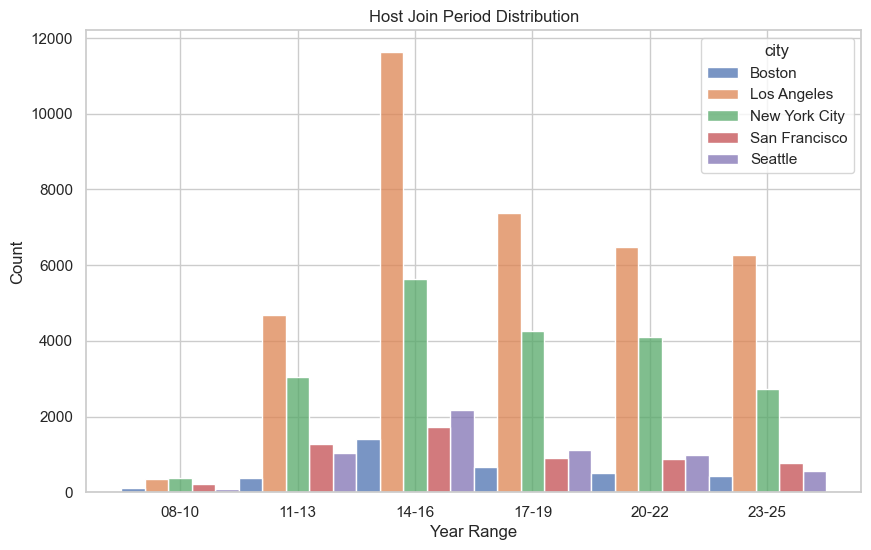

In [10]:
airbnb["host_since_year"] = airbnb["host_since"].dt.year

# count per year per city
bins = [2007, 2010, 2013, 2016, 2019, 2022, 2025]
labels = ["08-10", "11-13", "14-16", "17-19", "20-22", "23-25"]

airbnb["host_year_bin"] = pd.cut(
    airbnb["host_since_year"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# plot
plt.figure(figsize=(10, 6))
sns.histplot(
    data=airbnb,
    x="host_year_bin",
    hue="city",
    multiple="dodge"
)
plt.title("Host Join Period Distribution")
plt.xlabel("Year Range")
plt.ylabel("Count")
plt.show()

In [11]:
print(airbnb.groupby("city")["host_years"].mean())

print(airbnb.groupby("city")["host_years"].max() - airbnb.groupby("city")["host_years"].min())

city
Boston           8.729587
Los Angeles      8.020327
New York City    8.312099
San Francisco    9.048159
Seattle          9.047715
Name: host_years, dtype: float64
city
Boston           16.775342
Los Angeles      17.145205
New York City    17.057534
San Francisco    17.087671
Seattle          17.057534
Name: host_years, dtype: float64


# Check Time Consistency


In [12]:
airbnb.groupby("city")["last_scraped"].agg(["min", "max"])

,min,max
city,,
Boston,2025-09-23,2025-09-24
Los Angeles,2025-09-02,2025-09-03
New York City,2025-09-02,2025-09-03
San Francisco,2025-09-01,2025-09-01
Seattle,2025-09-25,2025-09-25


current data and analyse is only based on September info and might be able to imply part of results to other time period

# Price Distribution Across Cities

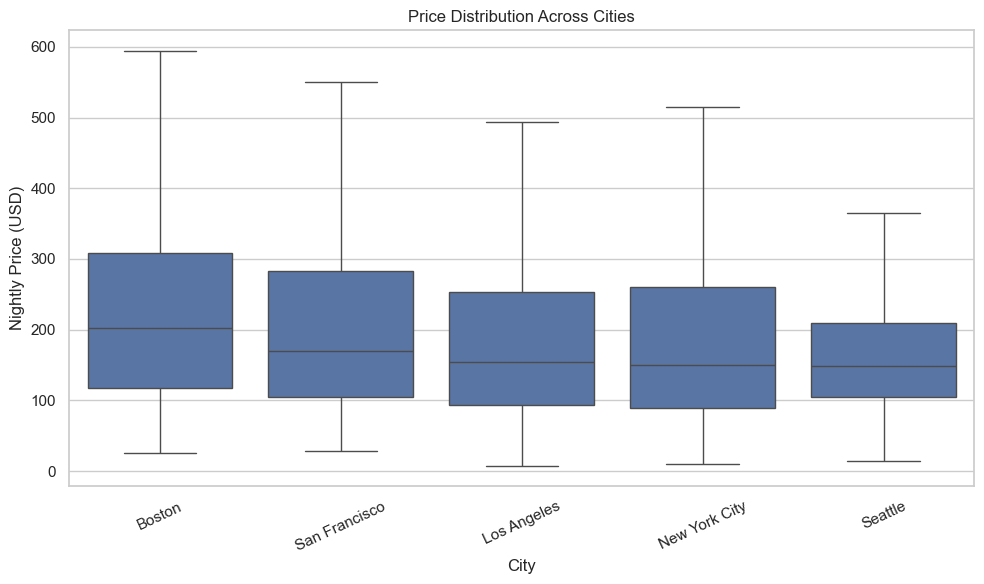

In [13]:
# clip extreme outliers for visualization only
upper = airbnb["price"].quantile(0.99)
price_plot = airbnb[airbnb["price"] <= upper].copy()

# order cities by median price
city_order = (
    price_plot.groupby("city")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=price_plot,
    x="city",
    y="price",
    order=city_order,
    showfliers=False
)

plt.title("Price Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Nightly Price (USD)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

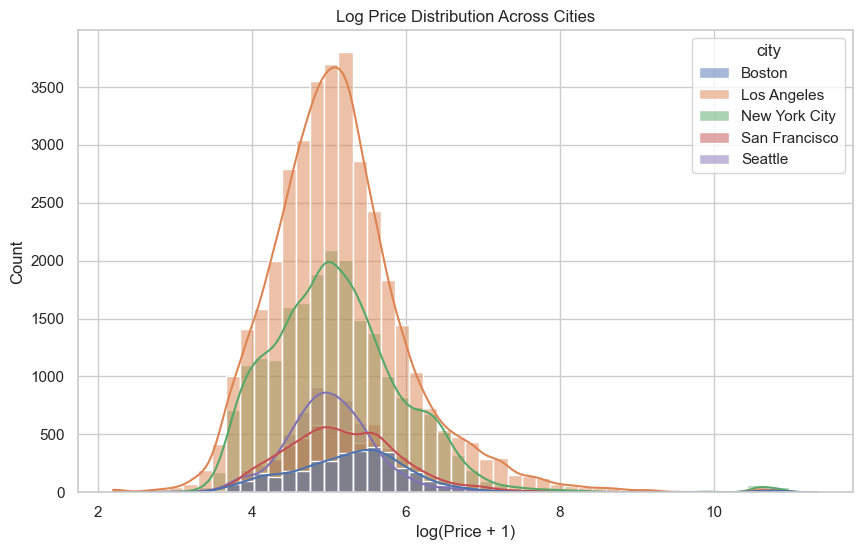

In [14]:
airbnb["log_price"] = np.log1p(airbnb["price"])

plt.figure(figsize=(10,6))
sns.histplot(data=airbnb, x="log_price", hue="city", bins=50, kde=True)
plt.title("Log Price Distribution Across Cities")
plt.xlabel("log(Price + 1)")
plt.ylabel("Count")
plt.show()

# Feature Distribution Across Cities

## pre cleaning 

In [15]:
na_summary = airbnb.isna().mean().sort_values(ascending=False)
na_summary

calendar_updated                                1.000000
license                                         0.638878
neighbourhood                                   0.516943
neighborhood_overview                           0.516943
host_about                                      0.422063
review_scores_location                          0.249313
review_scores_value                             0.249313
review_scores_checkin                           0.249286
review_scores_accuracy                          0.249258
review_scores_cleanliness                       0.249258
review_scores_communication                     0.249245
reviews_per_month                               0.249163
last_review                                     0.249163
review_scores_rating                            0.249163
first_review                                    0.249163
host_location                                   0.243502
host_neighbourhood                              0.183147
host_acceptance_rate           

In [ ]:
cols_drop = [
    "calendar_updated",
    "license",
    "neighborhood_overview",
    "neighbourhood",
    "host_about",
    "host_picture_url",
    "host_thumbnail_url",
    "host_name",
    "description",
    "host_verifications",
]

non_feature = [
    "id", "listing_url", "scrape_id", "source",
    "host_id", "host_url",
    "name", "picture_url"
]

date_metadata = [
    "calendar_last_scraped",
    "last_scraped"
]

cols_drop = cols_drop + non_feature + date_metadata

property_features = [
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "minimum_nights",
    "maximum_nights"
]

location_features = [
    "latitude",
    "longitude",
    "neighbourhood_cleansed"
]

review_features = [
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "has_reviews"
]

host_features = [
    "host_is_superhost",
    "host_identity_verified",
    "host_response_rate",
    "host_acceptance_rate",
    "host_listings_count",
    "host_has_profile_pic"
]

availability_features = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "instant_bookable"
]

target = ["price"]
key_cols = target + ["city"] + property_features + location_features + review_features + host_features + availability_features

In [17]:
airbnb_clean = airbnb.drop(columns=cols_drop, errors="ignore")

airbnb_clean.isna().mean().sort_values(ascending=False)

review_scores_location                          0.249313
review_scores_value                             0.249313
review_scores_checkin                           0.249286
review_scores_accuracy                          0.249258
review_scores_cleanliness                       0.249258
review_scores_communication                     0.249245
first_review                                    0.249163
reviews_per_month                               0.249163
last_review                                     0.249163
review_scores_rating                            0.249163
host_location                                   0.243502
host_neighbourhood                              0.183147
host_acceptance_rate                            0.131842
host_response_time                              0.129174
host_response_rate                              0.129174
neighbourhood_group_cleansed                    0.126575
host_is_superhost                               0.034444
host_years                     

## Room Type Distribution

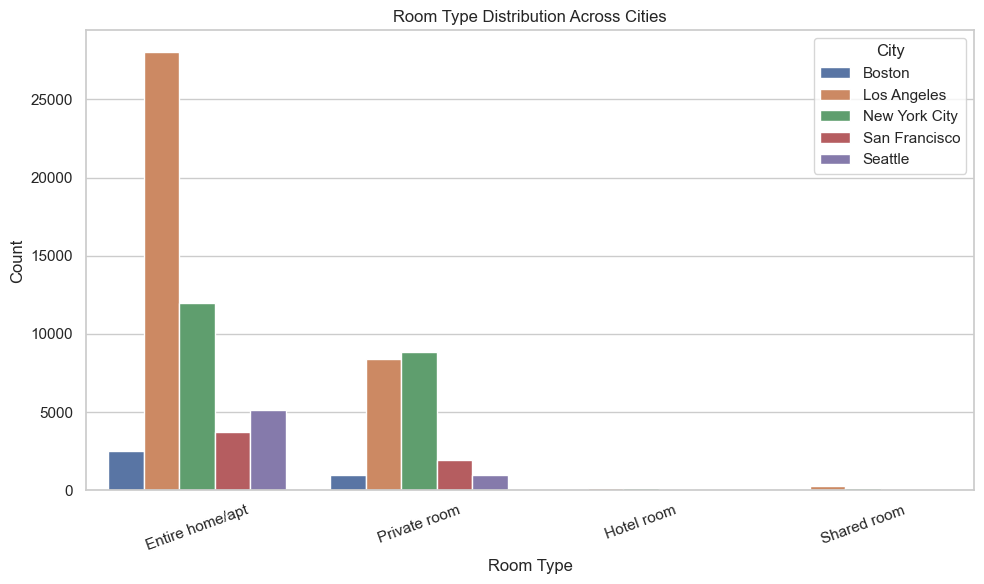

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=airbnb_clean,
    x="room_type",
    hue="city"
)

plt.title("Room Type Distribution Across Cities")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.legend(title="City")
plt.tight_layout()
plt.show()

## Accommodates

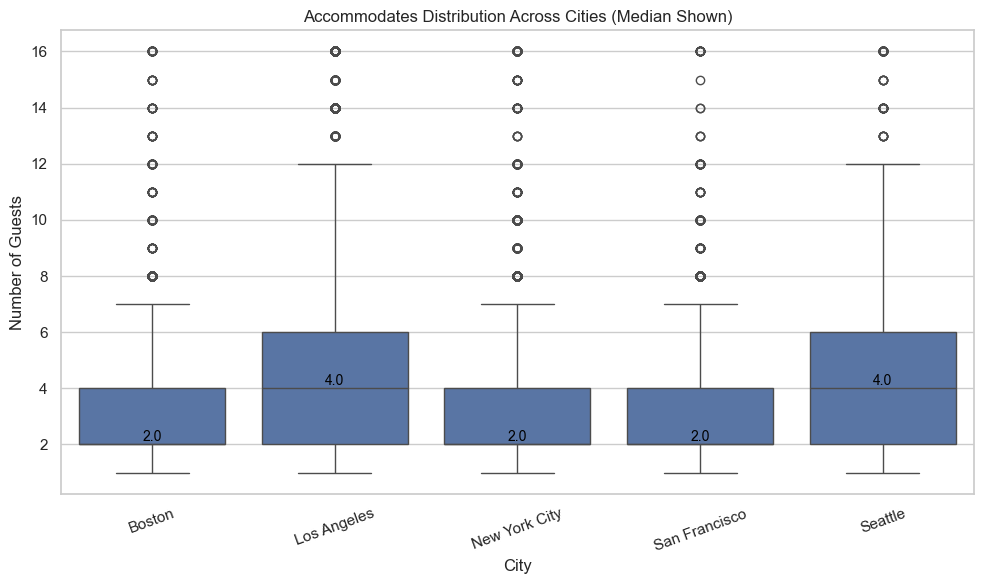

In [34]:
plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=airbnb_clean,
    x="city",
    y="accommodates"
)

# compute stats
stats = airbnb_clean.groupby("city")["accommodates"].describe()

# annotate median
for i, city in enumerate(stats.index):
    median = stats.loc[city, "50%"]
    ax.text(i, median, f"{median:.1f}", 
            ha='center', va='bottom', fontsize=10, color='black')

plt.title("Accommodates Distribution Across Cities (Median Shown)")
plt.xlabel("City")
plt.ylabel("Number of Guests")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [35]:
summary = airbnb_clean.groupby("city")["accommodates"].describe()[["25%", "50%", "75%"]]

print(summary)

               25%  50%  75%
city                        
Boston         2.0  2.0  4.0
Los Angeles    2.0  4.0  6.0
New York City  2.0  2.0  4.0
San Francisco  2.0  2.0  4.0
Seattle        2.0  4.0  6.0


## Number of Reviews

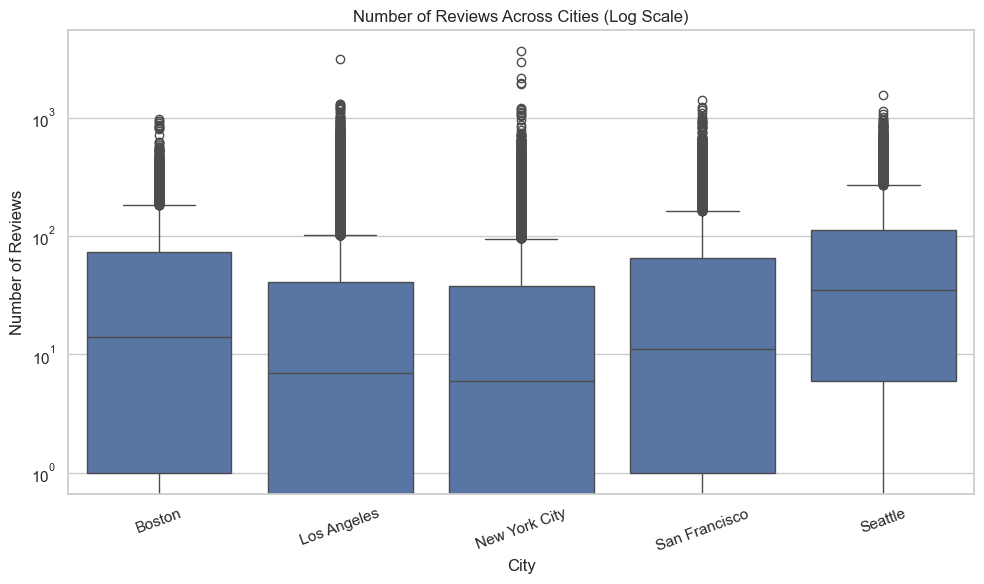

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=airbnb_clean,
    x="city",
    y="number_of_reviews"
)

plt.yscale("log")
plt.title("Number of Reviews Across Cities (Log Scale)")
plt.xlabel("City")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Review Score Rating

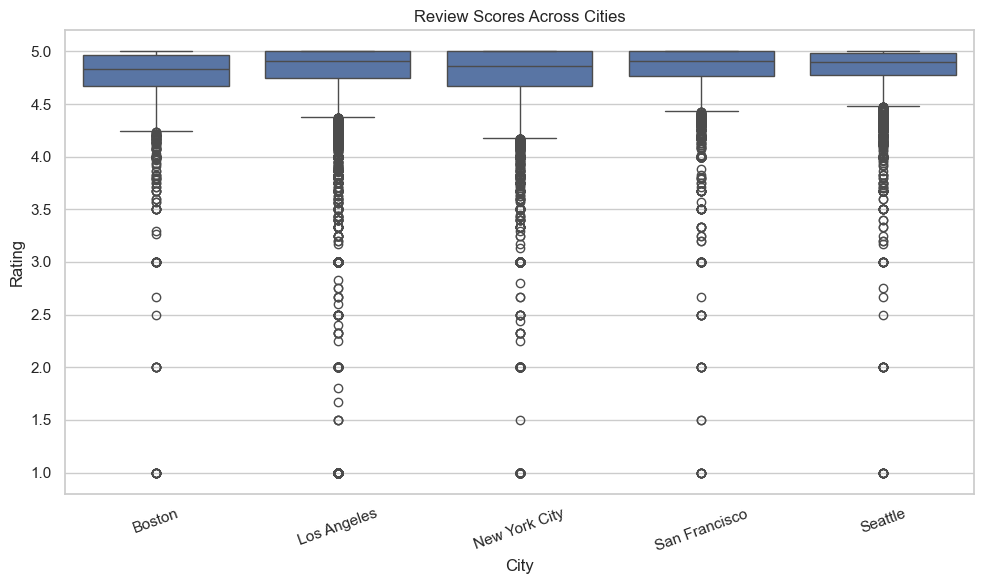

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=airbnb_clean,
    x="city",
    y="review_scores_rating"
)

plt.title("Review Scores Across Cities")
plt.xlabel("City")
plt.ylabel("Rating")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Availability (supply / occupancy proxy)

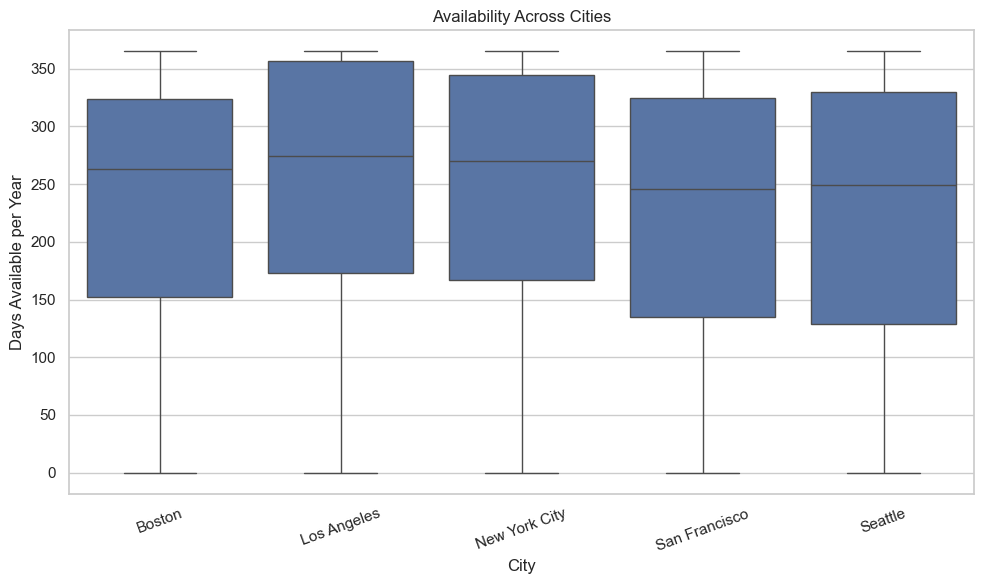

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=airbnb_clean,
    x="city",
    y="availability_365"
)

plt.title("Availability Across Cities")
plt.xlabel("City")
plt.ylabel("Days Available per Year")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Superhost Proportion

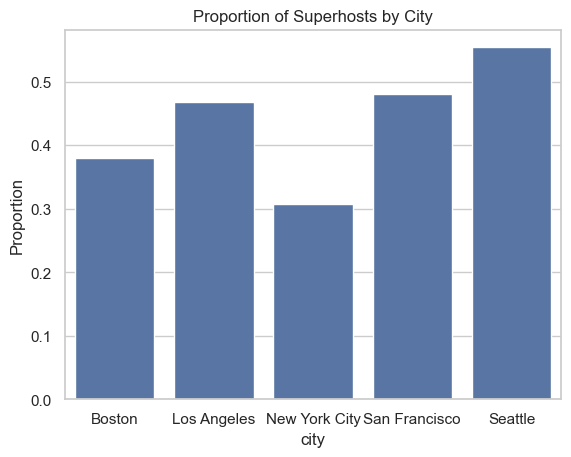

In [23]:
airbnb_clean["host_is_superhost"] = (
    airbnb_clean["host_is_superhost"]
    .map({"t": 1, "f": 0})
)
superhost_rate = airbnb_clean.groupby("city")["host_is_superhost"].mean()

sns.barplot(
    x=superhost_rate.index,
    y=superhost_rate.values
)

plt.title("Proportion of Superhosts by City")
plt.ylabel("Proportion")
plt.show()

# Feature–Price Relationships

## Property ones 

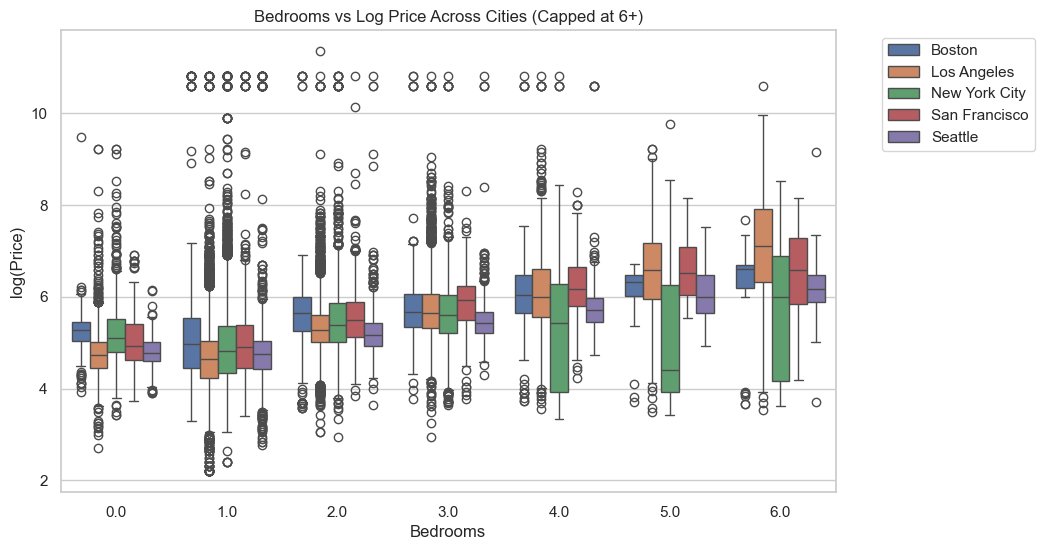

In [24]:
airbnb_clean["bedrooms_clean"] = airbnb_clean["bedrooms"].clip(upper=6)
airbnb_clean['log_price'] = np.log1p(airbnb_clean['price'])

plt.figure(figsize=(10,6))

sns.boxplot(
    data=airbnb_clean,
    x="bedrooms_clean",
    y="log_price",
    hue="city"
)

plt.title("Bedrooms vs Log Price Across Cities (Capped at 6+)")
plt.xlabel("Bedrooms")
plt.ylabel("log(Price)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

<Axes: xlabel='bedrooms_clean', ylabel='log_price'>

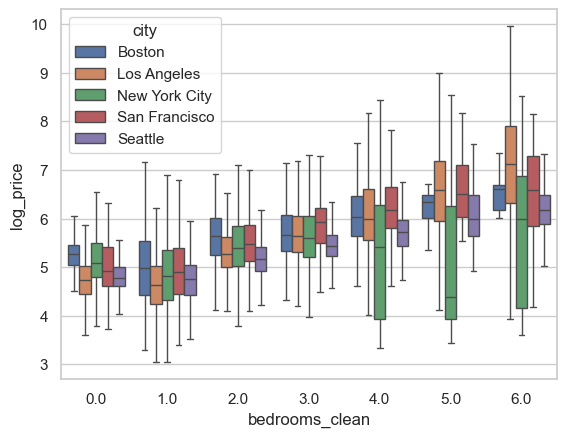

In [25]:
sns.boxplot(
    data=airbnb_clean,
    x="bedrooms_clean",
    y="log_price",
    hue="city",
    showfliers=False   
)

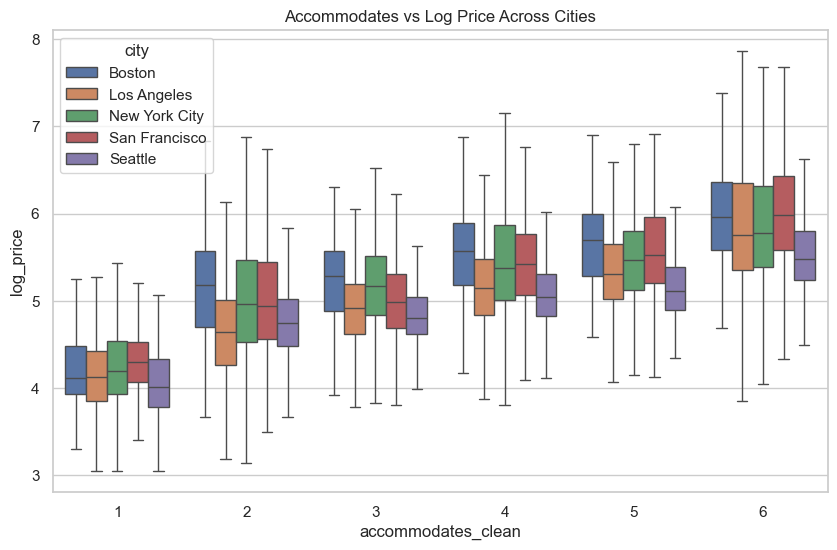

In [26]:
airbnb_clean["accommodates_clean"] = airbnb_clean["accommodates"].clip(upper=6)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=airbnb_clean,
    x="accommodates_clean",
    y="log_price",
    hue="city",
    showfliers=False
)
plt.title("Accommodates vs Log Price Across Cities")
plt.show()

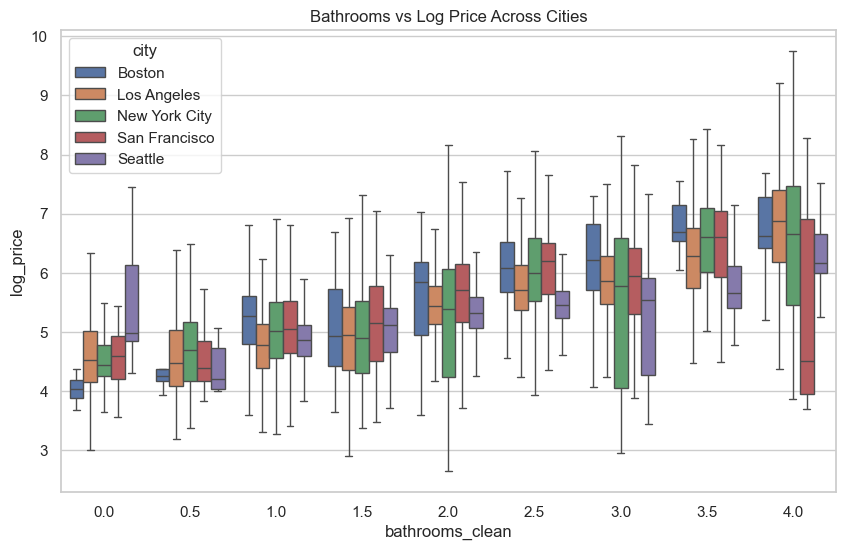

In [27]:
airbnb_clean["bathrooms_clean"] = airbnb_clean["bathrooms"].clip(upper=4)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=airbnb_clean,
    x="bathrooms_clean",
    y="log_price",
    hue="city",
    showfliers=False
)
plt.title("Bathrooms vs Log Price Across Cities")
plt.show()

## Location

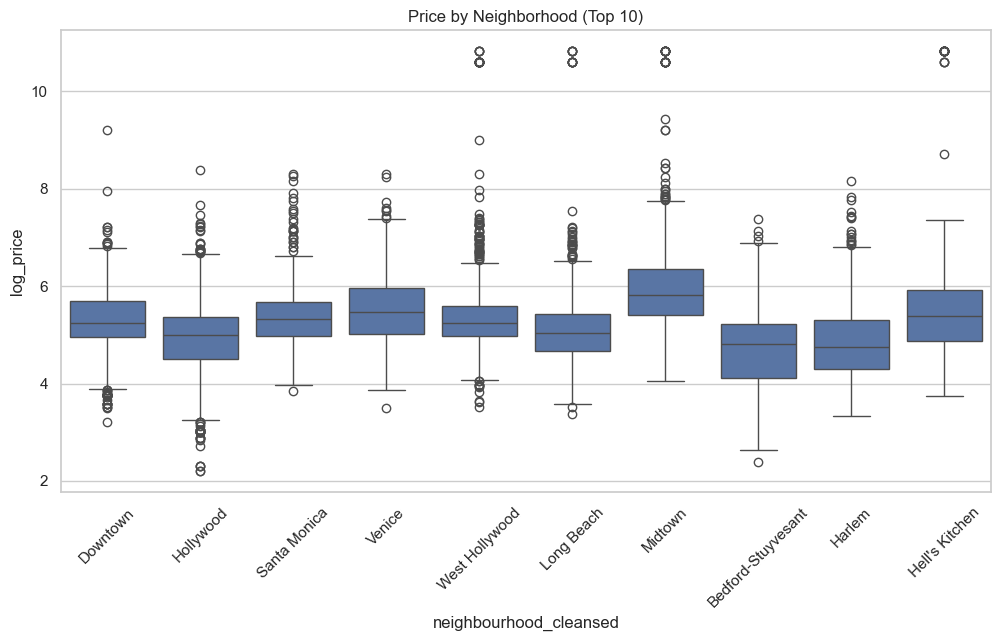

In [28]:
top_neigh = airbnb_clean["neighbourhood_cleansed"].value_counts().head(10).index

df_sub = airbnb_clean[airbnb_clean["neighbourhood_cleansed"].isin(top_neigh)]

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_sub,
    x="neighbourhood_cleansed",
    y="log_price"
)
plt.xticks(rotation=45)
plt.title("Price by Neighborhood (Top 10)")
plt.show()

# Review-related

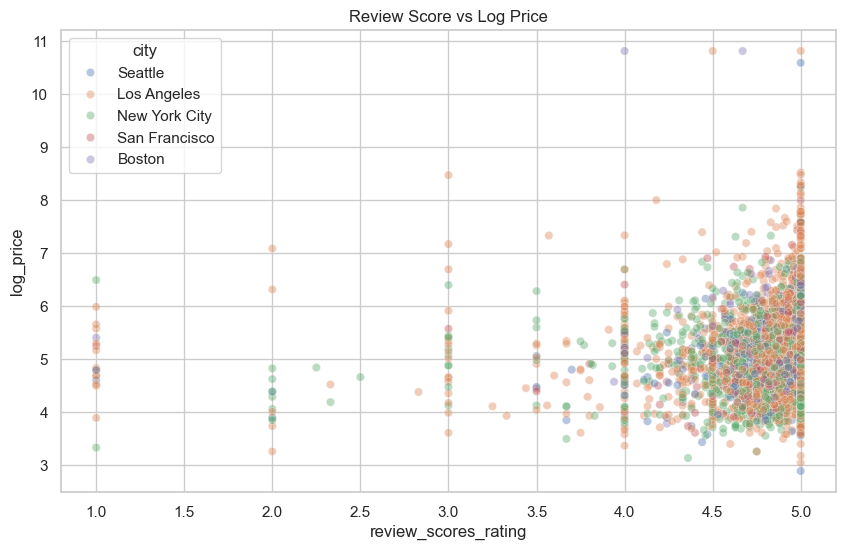

In [29]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=airbnb_clean.sample(5000),
    x="review_scores_rating",
    y="log_price",
    hue="city",
    alpha=0.4
)
plt.title("Review Score vs Log Price")
plt.show()

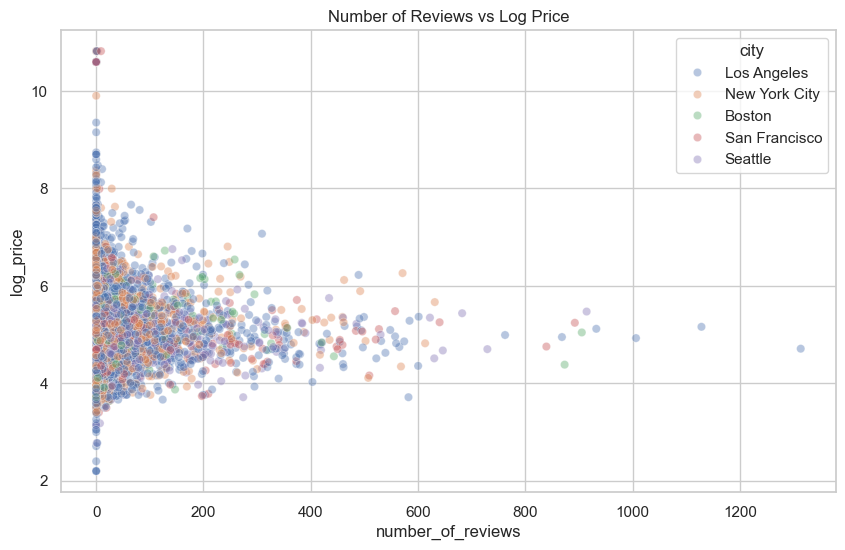

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=airbnb_clean.sample(5000),
    x="number_of_reviews",
    y="log_price",
    hue="city",
    alpha=0.4
)
plt.title("Number of Reviews vs Log Price")
plt.show()

## Listing Type

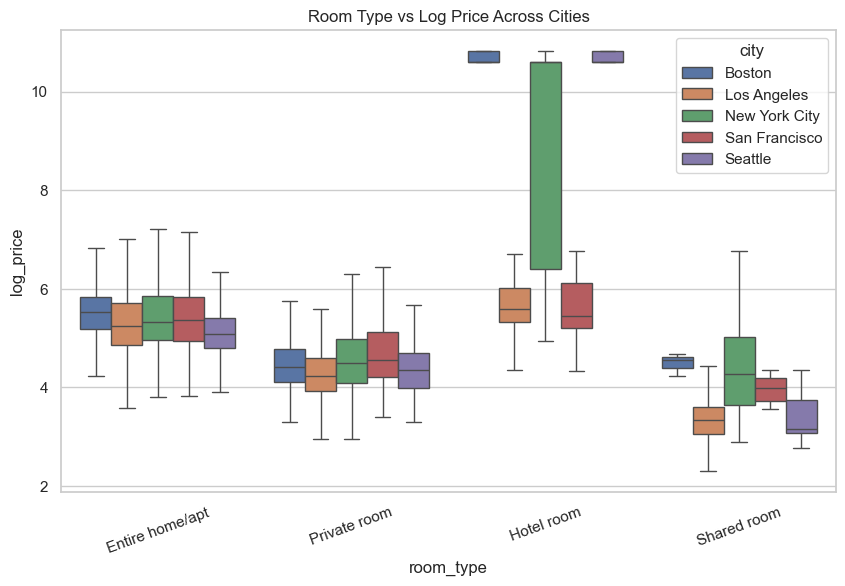

In [31]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=airbnb_clean,
    x="room_type",
    y="log_price",
    hue="city",
    showfliers=False
)
plt.title("Room Type vs Log Price Across Cities")
plt.xticks(rotation=20)
plt.show()

# Normalized Price Analysis

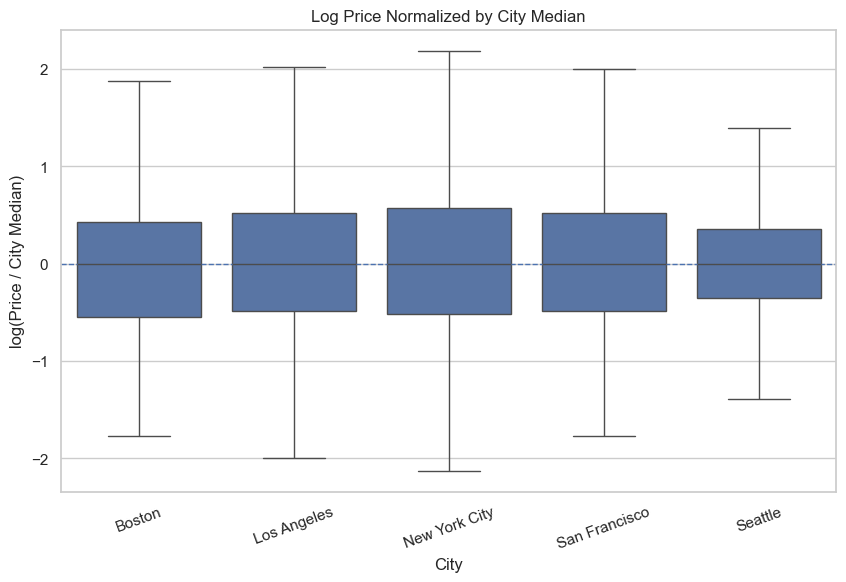

In [32]:
airbnb_clean["price_city_median"] = airbnb_clean.groupby("city")["price"].transform("median")
airbnb_clean["price_norm_median"] = airbnb_clean["price"] / airbnb_clean["price_city_median"]
airbnb_clean["log_price_norm_median"] = np.log(airbnb_clean["price_norm_median"])

plt.figure(figsize=(10,6))
sns.boxplot(
    data=airbnb_clean,
    x="city",
    y="log_price_norm_median",
    showfliers=False
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Log Price Normalized by City Median")
plt.xlabel("City")
plt.ylabel("log(Price / City Median)")
plt.xticks(rotation=20)
plt.show()

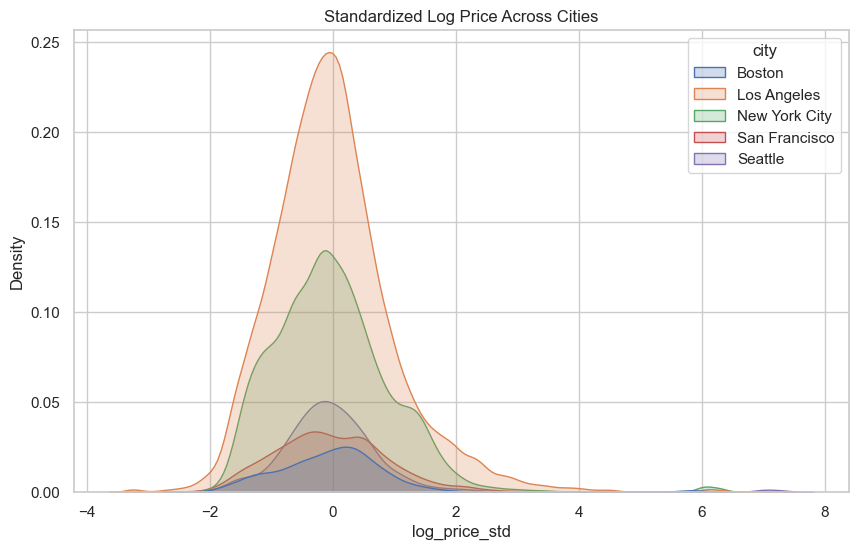

In [33]:
# log with standarize
from sklearn.preprocessing import StandardScaler

airbnb_clean["log_price"] = np.log1p(airbnb_clean["price"])

airbnb_clean["log_price_std"] = airbnb_clean.groupby("city")["log_price"].transform(
    lambda x: (x - x.mean()) / x.std()
)

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=airbnb_clean,
    x="log_price_std",
    hue="city",
    fill=True
)
plt.title("Standardized Log Price Across Cities")
plt.show()

## Heatmap

In [36]:
property_features = [
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "minimum_nights",
    "maximum_nights"
]

location_features = [
    "latitude",
    "longitude",
    "neighbourhood_cleansed"
]

review_features = [
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "has_reviews"
]

host_features = [
    "host_is_superhost",
    "host_identity_verified",
    "host_response_rate",
    "host_acceptance_rate",
    "host_listings_count",
    "host_has_profile_pic"
]

availability_features = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "instant_bookable"
]

target = ["price", "log_price"]

key_cols = (
    target + ["city"] +
    property_features +
    location_features +
    review_features +
    host_features +
    availability_features
)

# keep only columns that actually exist
key_cols = [c for c in key_cols if c in airbnb_clean.columns]

eda_model = airbnb_clean[key_cols].copy()

In [37]:
# ================================
# 2. Convert boolean / percentage columns
# ================================

bool_cols = [
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "instant_bookable"
]

for col in bool_cols:
    if col in eda_model.columns:
        eda_model[col] = eda_model[col].map({"t": 1, "f": 0, True: 1, False: 0})

percent_cols = ["host_response_rate", "host_acceptance_rate"]

for col in percent_cols:
    if col in eda_model.columns:
        eda_model[col] = (
            eda_model[col]
            .astype(str)
            .str.replace("%", "", regex=False)
        )
        eda_model[col] = pd.to_numeric(eda_model[col], errors="coerce") / 100

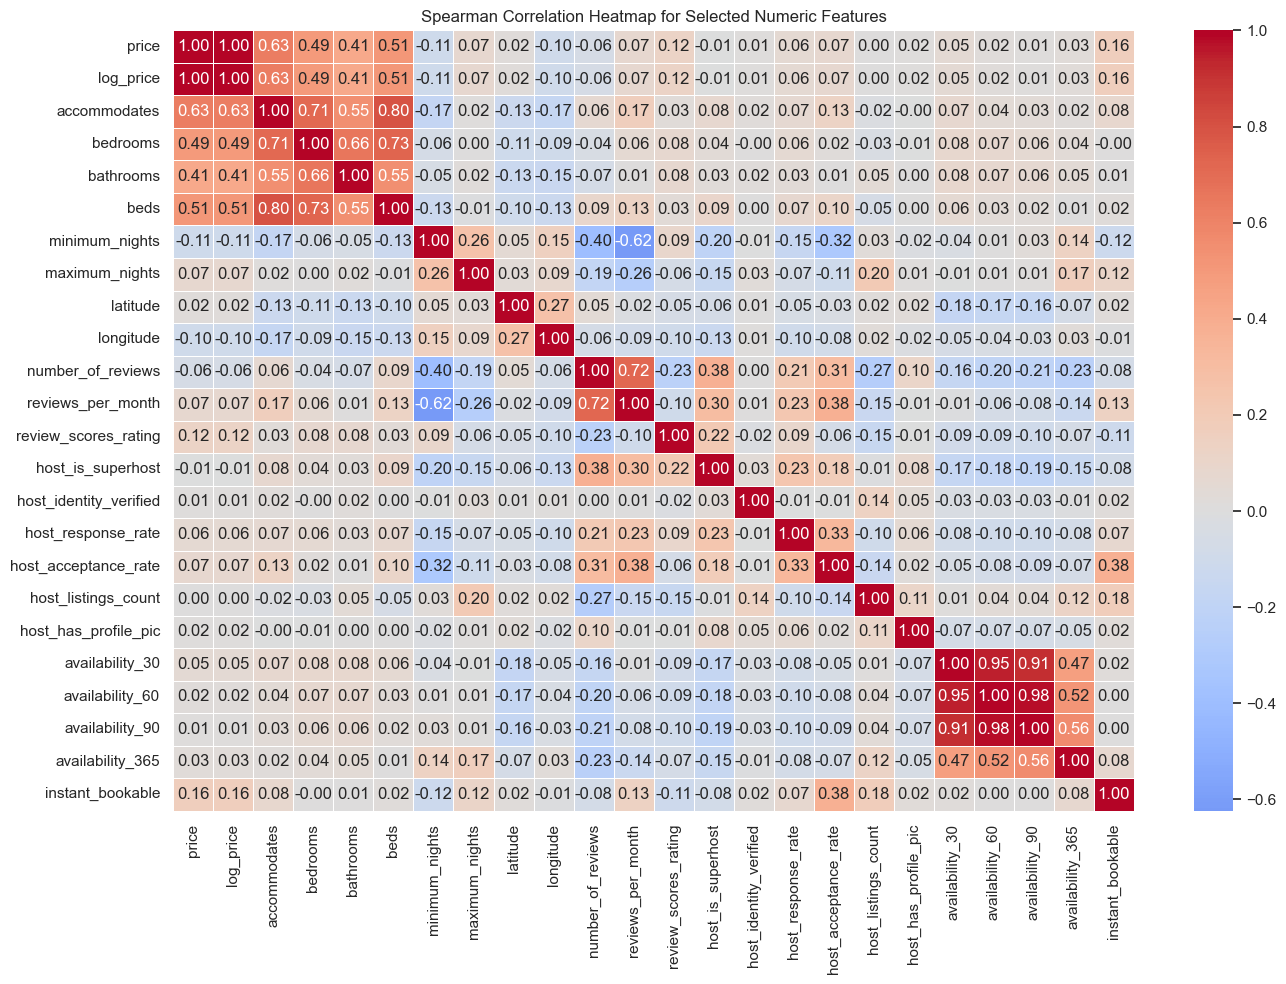

In [38]:
# ================================
# 3. Numeric correlation heatmap
# ================================

numeric_df = eda_model.select_dtypes(include=["number"]).copy()

# optional: remove raw price and focus on log_price
corr = numeric_df.corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap for Selected Numeric Features")
plt.tight_layout()
plt.show()

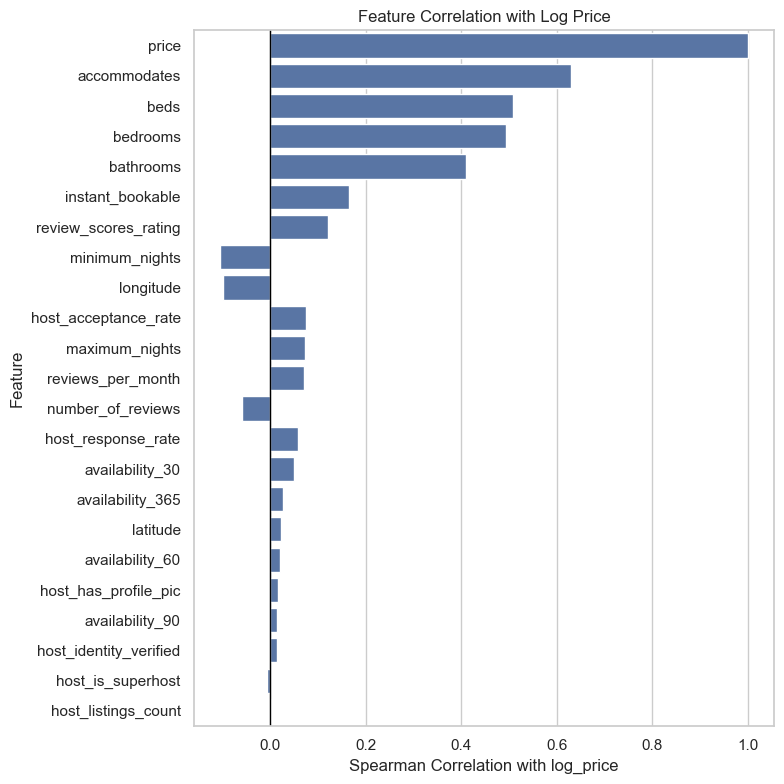

price                     1.000000
accommodates              0.629966
beds                      0.508355
bedrooms                  0.493415
bathrooms                 0.410370
instant_bookable          0.164936
review_scores_rating      0.120041
minimum_nights           -0.105101
longitude                -0.098315
host_acceptance_rate      0.074097
maximum_nights            0.072383
reviews_per_month         0.070289
number_of_reviews        -0.058797
host_response_rate        0.057328
availability_30           0.049631
availability_365          0.026259
latitude                  0.022474
availability_60           0.020479
host_has_profile_pic      0.015555
availability_90           0.013268
host_identity_verified    0.013178
host_is_superhost        -0.007165
host_listings_count       0.001664
Name: log_price, dtype: float64

In [39]:
# ================================
# 4. Correlation with log_price only
# ================================

price_corr = (
    corr["log_price"]
    .drop("log_price")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

plt.figure(figsize=(8, 8))
sns.barplot(
    x=price_corr.values,
    y=price_corr.index
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Feature Correlation with Log Price")
plt.xlabel("Spearman Correlation with log_price")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

price_corr

### Final Feature Set 

Target: price, log price

Features: (linear model would be different set)
1. accomodation, bedroom, bathroom, beds 
2. minimum_nights
3. review_scores_rating, number_of_reviews
4. host_acceptance_rate, host_response_rate, host_has_profile_pic, host_since_year (~ superhost)
5. avalability_365
6. neigborhood_cleasensed (change to toursim)
7. room_type {drop hotel room and shared room (only keep entire and private only)}


In [ ]:
tourist_neighborhoods = {
    "Boston": [
        "Back Bay", "Beacon Hill", "Downtown", "North End",
        "Fenway", "South End", "Waterfront"
    ],
    "Los Angeles": [
        "Hollywood", "Venice", "Santa Monica", "Beverly Hills",
        "Downtown", "West Hollywood", "Silver Lake"
    ],
    "New York City": [
        "Midtown", "Theater District", "Chelsea", "West Village",
        "East Village", "SoHo", "Upper West Side", "Upper East Side",
        "Financial District", "Greenwich Village"
    ],
    "San Francisco": [
        "Mission", "North Beach", "Financial District",
        "Nob Hill", "South of Market", "Marina", "Castro/Upper Market"
    ],
    "Seattle": [
        "Downtown", "Capitol Hill", "Belltown", "Pike-Market",
        "Queen Anne", "South Lake Union"
    ]
}

airbnb_clean["tourist_area"] = airbnb_clean.apply(
    lambda row: int(
        row["neighbourhood_cleansed"] in tourist_neighborhoods.get(row["city"], [])
    ),
    axis=1
)